# Fine-tuning de Vision Transformer con MLflow

Un **Vision Transformer (ViT)** aplica la arquitectura Transformer a tareas de visión. La imagen se divide en parches, cada parche se transforma en un token y el mecanismo de *self-attention* aprende las relaciones entre ellos.

## Modelo preentrenado

Utilizaremos [DeiT-Tiny](https://huggingface.co/facebook/deit-tiny-patch16-224), una versión pequeña de ViT preentrenada para clasificación de imágenes. Mediante **fine-tuning** adaptaremos sus pesos al dataset [Beans](https://huggingface.co/datasets/AI-Lab-Makerere/beans), que contiene tres clases de hojas.

## Seguimiento con MLflow

[MLflow](https://mlflow.org/) permite registrar parámetros, métricas, artefactos y uso del sistema. Compararemos loss y accuracy de train, validation y test durante el aprendizaje. La selección del mejor modelo dependerá exclusivamente de validation.

El objetivo es mostrar la estructura básica de un entrenamiento con un ViT preentrenado y el seguimiento de sus resultados.

In [80]:
%pip install -q torch transformers datasets mlflow matplotlib seaborn scikit-learn psutil nvidia-ml-py

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Parámetros

Los valores se definen en un único lugar para facilitar la comparación entre corridas.

In [81]:
MODEL_NAME = "facebook/deit-tiny-patch16-224"  # Modelo preentrenado de Hugging Face
DATASET_NAME = "beans"                        # Dataset que se utilizará
TRAIN_SPLIT = "train"           # Split oficial usado para ajustar el modelo
VALIDATION_SPLIT = "validation" # Split usado para controlar la generalización
TEST_SPLIT = "test"             # Split mostrado como referencia, no para decidir

TRAIN_SAMPLES = 300       # Cantidad de imágenes de entrenamiento
VALIDATION_SAMPLES = 100  # Cantidad de imágenes de validación
TEST_SAMPLES = 100        # Cantidad de imágenes de test

EPOCHS = 2             # Cantidad de recorridos completos sobre train
BATCH_SIZE = 8         # Cantidad de imágenes procesadas por paso
LEARNING_RATE = 5e-5   # Tamaño de la actualización de los pesos
SEED = 42              # Semilla para obtener resultados reproducibles

METRIC_AVERAGE = "macro"          # Da el mismo peso a cada clase
WEIGHTED_AVERAGE = "weighted"     # Pondera cada clase según su cantidad de ejemplos
EXPERIMENT_NAME = "TP4-ViT"       # Nombre del experimento en MLflow
RUN_NAME = "deit-tiny-baseline"   # Nombre de esta ejecución en MLflow

NUM_EXAMPLES = 3  # Cantidad de imágenes mostradas en la visualización

## 1. Dispositivo y dataset

Se utiliza GPU cuando está disponible.

`beans` ya contiene splits oficiales de **train**, **validation** y **test**. Train actualiza los pesos y validation controla la generalización. En este ejemplo también mostramos test por época para comparar las curvas, pero no se utiliza para elegir el modelo ni ajustar parámetros.

Para acelerar el ejemplo tomamos una muestra estratificada de cada split. Así se conserva aproximadamente la proporción de clases y las imágenes nunca se mezclan entre conjuntos.

In [82]:
# Librerías para entrenamiento, métricas y seguimiento
import copy
import random
import tempfile
from collections import Counter

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from torch.utils.data import DataLoader
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Las semillas permiten repetir el experimento
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

# El dataset ya incluye los tres splits oficiales
dataset = load_dataset(DATASET_NAME)

# Se reduce cada split por separado; sus imágenes nunca se mezclan
def stratified_subset(split, size):
    # Conserva aproximadamente la proporción original de cada clase
    if size >= len(split):
        return split
    return split.train_test_split(
        train_size=size, stratify_by_column="labels", seed=SEED
    )["train"]

train_data = stratified_subset(dataset[TRAIN_SPLIT], TRAIN_SAMPLES)
validation_data = stratified_subset(dataset[VALIDATION_SPLIT], VALIDATION_SAMPLES)
test_data = stratified_subset(dataset[TEST_SPLIT], TEST_SAMPLES)

# Las clases se obtienen directamente del dataset
classes = dataset[TRAIN_SPLIT].features["labels"].names
print("Clases:", classes)

Dispositivo: cuda
Clases: ['angular_leaf_spot', 'bean_rust', 'healthy']


## 2. Visualización

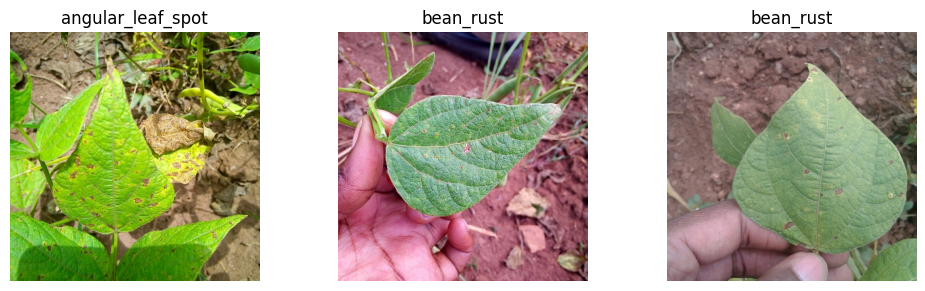

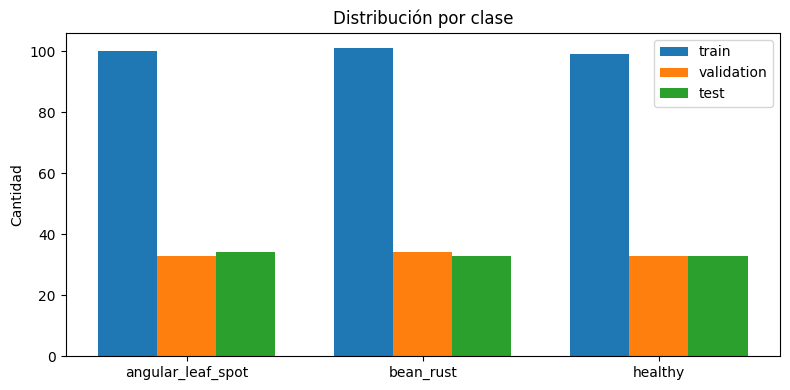

In [83]:
# Se observan algunas imágenes antes de entrenar
sample_figure, axes = plt.subplots(1, NUM_EXAMPLES, figsize=(10, 3))
for sample, ax in zip(train_data.select(range(NUM_EXAMPLES)), axes):
    ax.imshow(sample["image"])
    ax.set_title(classes[sample["labels"]])
    ax.axis("off")
plt.tight_layout()
plt.show()

# Distribución de clases de cada subconjunto
splits_data = {"train": train_data, "validation": validation_data, "test": test_data}
class_distribution = {}
for split_name, split in splits_data.items():
    counts = Counter(split["labels"])
    class_distribution[split_name] = {
        class_name: counts.get(class_id, 0)
        for class_id, class_name in enumerate(classes)
    }
distribution_figure, ax = plt.subplots(figsize=(8, 4))
positions = np.arange(len(classes))
for offset, (name, counts) in zip([-0.25, 0, 0.25], class_distribution.items()):
    values = [counts[class_name] for class_name in classes]
    ax.bar(positions + offset, values, width=0.25, label=name)
ax.set(xticks=positions, xticklabels=classes, ylabel="Cantidad", title="Distribución por clase")
ax.legend()
distribution_figure.tight_layout()
plt.show()

## 3. Modelo y datos

El procesador adapta las imágenes al formato del ViT. Reemplazamos su clasificador para trabajar con tres clases.

In [84]:
# Aplica el tamaño y la normalización esperados por el modelo
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

# Convierte imágenes y etiquetas en tensores agrupados por lote
def collate_fn(samples):
    batch = processor([x["image"].convert("RGB") for x in samples], return_tensors="pt")
    batch["labels"] = torch.tensor([x["labels"] for x in samples])
    return batch

# Los DataLoaders entregan los datos en lotes
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, collate_fn=collate_fn)

# Relación explícita entre índices y nombres de clase
id2label = {index: name for index, name in enumerate(classes)}
label2id = {name: index for index, name in id2label.items()}

# Se reemplaza el clasificador original por uno con tres salidas
model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME, num_labels=len(classes), id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)

# AdamW actualiza los pesos durante el fine-tuning
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTForImageClassification were not initialized from the model checkpoint at facebook/deit-tiny-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 192]) in the checkpoint and torch.Size([3, 192]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 4. Entrenamiento y evaluación

Sólo durante train se calculan gradientes y se actualizan los pesos. Validation y test se ejecutan sin gradientes.

In [85]:
def run_epoch(loader, training=False):
    # Activa o desactiva el modo de entrenamiento
    model.train(training)
    loss_sum, correct, total = 0, 0, 0
    labels, predictions = [], []

    for batch in loader:
        # Mueve imágenes y etiquetas a GPU o CPU
        batch = {key: value.to(device) for key, value in batch.items()}

        # Los gradientes sólo son necesarios durante train
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            output = model(**batch)
            if training:
                output.loss.backward()
                optimizer.step()

        # Clase con mayor puntuación para cada imagen
        predicted = output.logits.argmax(1)
        batch_size = batch["labels"].size(0)
        loss_sum += output.loss.item() * batch_size
        correct += (predicted == batch["labels"]).sum().item()
        total += batch_size
        labels.extend(batch["labels"].cpu().tolist())
        predictions.extend(predicted.cpu().tolist())

    # Promedios y valores necesarios para calcular otras métricas
    return loss_sum / total, correct / total, labels, predictions


def calculate_metrics(split, results):
    # Calcula las mismas métricas para cada split
    loss, accuracy, labels, predictions = results
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average=METRIC_AVERAGE, zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average=WEIGHTED_AVERAGE, zero_division=0
    )
    metrics = {
        f"{split}_loss": float(loss),
        f"{split}_accuracy": float(accuracy),
        f"{split}_precision_macro": float(precision),
        f"{split}_recall_macro": float(recall),
        f"{split}_f1_macro": float(f1),
        f"{split}_f1_weighted": float(f1_weighted),
    }
    return metrics, labels, predictions

## 5. Métricas

Registramos loss, accuracy, precision macro, recall macro y F1 macro para train, validation y test. El promedio **macro** da la misma importancia a cada clase y evita la redundancia de las métricas micro con accuracy.

También guardamos F1 weighted como referencia ante desbalance, una matriz de confusión y el reporte por clase. Una loss de validation creciente mientras train mejora puede indicar overfitting.

## 6. MLflow

La corrida registra **parámetros**, **métricas**, **tags** y **artefactos**. Las mismas métricas se calculan para train, validation y test.

También se activa el registro de métricas del sistema. MLflow guarda uso de CPU y memoria; si existe una GPU compatible, también registra su utilización y memoria.

2026/09/14 18:39:00 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


Época 1: train_loss=0.209 - validation_loss=0.322
Época 2: train_loss=0.063 - validation_loss=0.144


2026/09/14 18:39:26 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/09/14 18:39:26 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


Train: {'train_loss': 0.06264508880674839, 'train_accuracy': 0.9933333333333333, 'train_precision_macro': 0.9933333333333333, 'train_recall_macro': 0.9933663366336635, 'train_f1_macro': 0.9933332499979167, 'train_f1_weighted': 0.99333341666875}
Validation: {'validation_loss': 0.1438518738746643, 'validation_accuracy': 0.97, 'validation_precision_macro': 0.9699940582293524, 'validation_recall_macro': 0.9702911467617351, 'validation_f1_macro': 0.969998492386552, 'validation_f1_weighted': 0.9698507462686569}
Test: {'test_loss': 0.3120742264389992, 'test_accuracy': 0.88, 'test_precision_macro': 0.8891163037504501, 'test_recall_macro': 0.8790849673202614, 'test_f1_macro': 0.8776510871426125, 'test_f1_weighted': 0.8776745762711865}
                   precision    recall  f1-score   support

angular_leaf_spot       0.80      0.97      0.88        34
        bean_rust       0.92      0.73      0.81        33
          healthy       0.94      0.94      0.94        33

         accuracy         

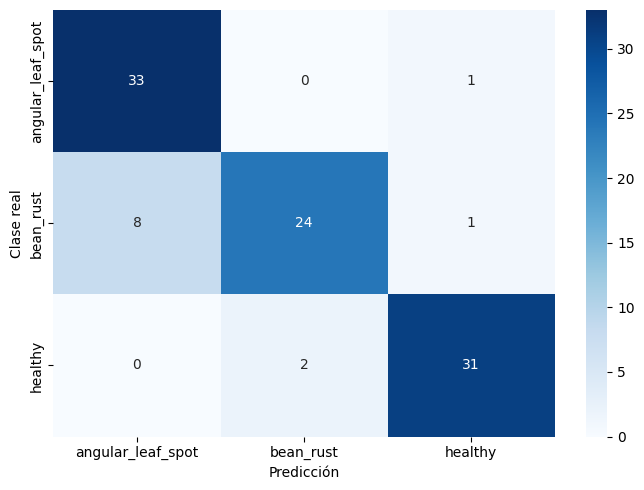

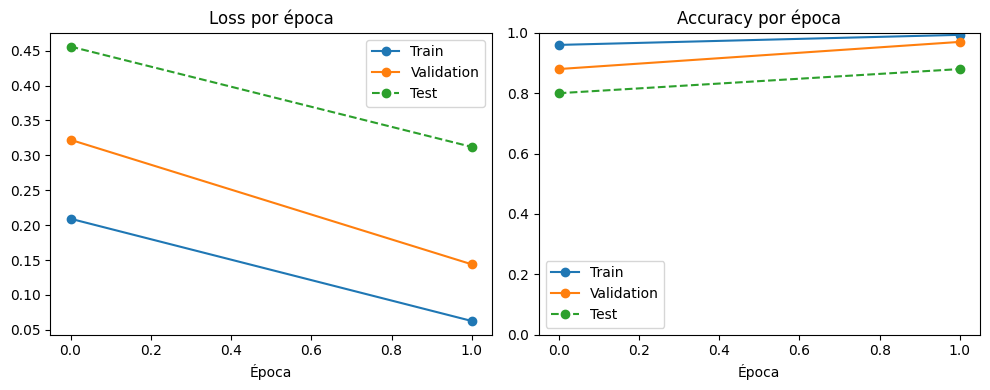

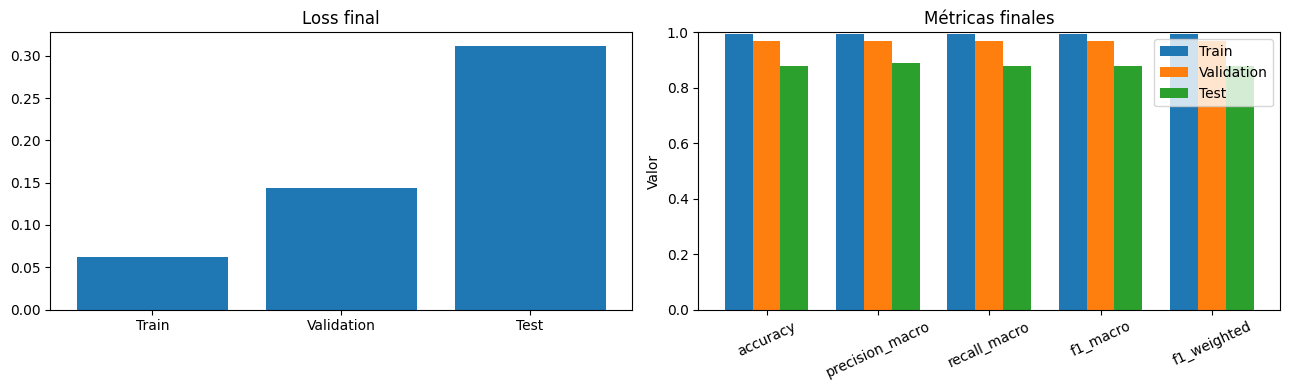

In [86]:
mlflow.set_experiment(EXPERIMENT_NAME)

# MLflow registra CPU, memoria y GPU durante la ejecución
with mlflow.start_run(run_name=RUN_NAME, log_system_metrics=True):
    # Parámetros y etiquetas de la corrida
    mlflow.log_params({
        "model": MODEL_NAME, "dataset": DATASET_NAME,
        "epochs": EPOCHS, "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE, "train_samples": TRAIN_SAMPLES,
        "validation_samples": VALIDATION_SAMPLES, "test_samples": TEST_SAMPLES,
        "seed": SEED,
        "metric_average": METRIC_AVERAGE,
        "weighted_average": WEIGHTED_AVERAGE,
    })
    mlflow.set_tags({"task": "image-classification", "architecture": "ViT"})

    # Artefactos iniciales
    mlflow.log_figure(sample_figure, "dataset/examples.png")
    mlflow.log_figure(distribution_figure, "dataset/class_distribution.png")
    mlflow.log_dict({"classes": classes}, "dataset/classes.json")
    mlflow.log_dict(class_distribution, "dataset/class_distribution.json")
    mlflow.log_dict(model.config.to_dict(), "model/config.json")

    # Train y validation se comparan después de cada época
    history = {
        "train_loss": [], "validation_loss": [], "test_loss": [],
        "train_accuracy": [], "validation_accuracy": [], "test_accuracy": [],
    }
    best_validation_loss = float("inf")
    best_state = None
    best_epoch = 0
    for epoch in range(EPOCHS):
        run_epoch(train_loader, training=True)
        train_metrics, _, _ = calculate_metrics("train", run_epoch(train_loader))
        validation_metrics, _, _ = calculate_metrics("validation", run_epoch(validation_loader))
        test_epoch_metrics, _, _ = calculate_metrics("test", run_epoch(test_loader))
        epoch_metrics = {**train_metrics, **validation_metrics, **test_epoch_metrics}
        mlflow.log_metrics(epoch_metrics, step=epoch)
        for name in history:
            history[name].append(epoch_metrics[name])
        # Conserva el modelo con menor loss de validation
        if validation_metrics["validation_loss"] < best_validation_loss:
            best_validation_loss = validation_metrics["validation_loss"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        print(f"Época {epoch + 1}: train_loss={train_metrics['train_loss']:.3f} - "
              f"validation_loss={validation_metrics['validation_loss']:.3f}")

    # Restaura el mejor modelo antes de la evaluación final
    model.load_state_dict(best_state)
    train_metrics, _, _ = calculate_metrics("train", run_epoch(train_loader))
    validation_metrics, _, _ = calculate_metrics("validation", run_epoch(validation_loader))
    mlflow.log_metrics({**train_metrics, **validation_metrics}, step=EPOCHS)
    mlflow.log_param("best_epoch", best_epoch)

    # Evaluación final de test con el mejor modelo restaurado
    test_metrics, y_true, y_pred = calculate_metrics("test", run_epoch(test_loader))
    mlflow.log_metrics(test_metrics, step=EPOCHS)
    report = classification_report(
        y_true, y_pred, labels=range(len(classes)), target_names=classes,
        output_dict=True, zero_division=0
    )

    # Matriz de confusión del conjunto de test
    confusion_figure, ax = plt.subplots(figsize=(7, 5))
    matrix = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set(xlabel="Predicción", ylabel="Clase real")
    confusion_figure.tight_layout()

    # Curvas para observar aprendizaje y posible overfitting
    curve_figure, curve_axes = plt.subplots(1, 2, figsize=(10, 4))
    curve_axes[0].plot(history["train_loss"], marker="o", label="Train")
    curve_axes[0].plot(history["validation_loss"], marker="o", label="Validation")
    curve_axes[0].plot(history["test_loss"], marker="o", linestyle="--", label="Test")
    curve_axes[0].set(title="Loss por época", xlabel="Época")
    curve_axes[1].plot(history["train_accuracy"], marker="o", label="Train")
    curve_axes[1].plot(history["validation_accuracy"], marker="o", label="Validation")
    curve_axes[1].plot(history["test_accuracy"], marker="o", linestyle="--", label="Test")
    curve_axes[1].set(title="Accuracy por época", xlabel="Época", ylim=(0, 1))
    for axis in curve_axes:
        axis.legend()
    curve_figure.tight_layout()

    # Comparación final de train, validation y test
    metric_names = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]
    comparison_figure, (loss_ax, score_ax) = plt.subplots(1, 2, figsize=(13, 4))
    splits = [("Train", train_metrics), ("Validation", validation_metrics), ("Test", test_metrics)]
    loss_ax.bar([name for name, _ in splits], [values[f"{name.lower()}_loss"] for name, values in splits])
    loss_ax.set_title("Loss final")
    positions = list(range(len(metric_names)))
    for offset, (name, values) in zip([-0.25, 0, 0.25], splits):
        score_ax.bar([x + offset for x in positions],
                     [values[f"{name.lower()}_{metric}"] for metric in metric_names],
                     width=0.25, label=name)
    score_ax.set(xticks=positions, xticklabels=metric_names, ylim=(0, 1), ylabel="Valor")
    score_ax.tick_params(axis="x", rotation=25)
    score_ax.set_title("Métricas finales")
    score_ax.legend()
    comparison_figure.tight_layout()

    # Los gráficos y reportes quedan disponibles como artefactos
    mlflow.log_figure(curve_figure, "results/learning_curves.png")
    mlflow.log_figure(confusion_figure, "results/confusion_matrix.png")
    mlflow.log_figure(comparison_figure, "results/train_validation_test.png")
    mlflow.log_dict({"train": train_metrics, "validation": validation_metrics,
                     "test": test_metrics}, "results/metrics.json")
    mlflow.log_dict(report, "results/classification_report.json")
    mlflow.log_text(f"Fine-tuning de {MODEL_NAME} sobre {DATASET_NAME}.", "results/summary.txt")

    # Guarda el mejor modelo y su procesador como artefactos
    with tempfile.TemporaryDirectory() as model_dir:
        model.save_pretrained(model_dir)
        processor.save_pretrained(model_dir)
        mlflow.log_artifacts(model_dir, artifact_path="model")

print("Train:", train_metrics)
print("Validation:", validation_metrics)
print("Test:", test_metrics)
print(classification_report(y_true, y_pred, labels=range(len(classes)),
                            target_names=classes, zero_division=0))

## 7. Resultado

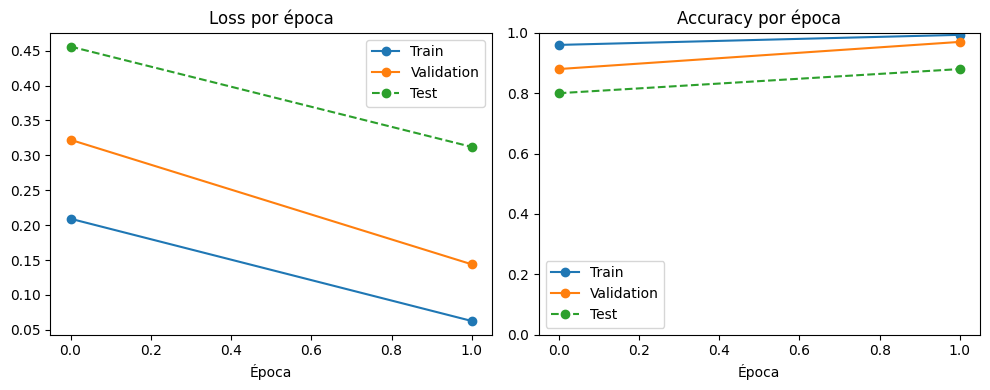

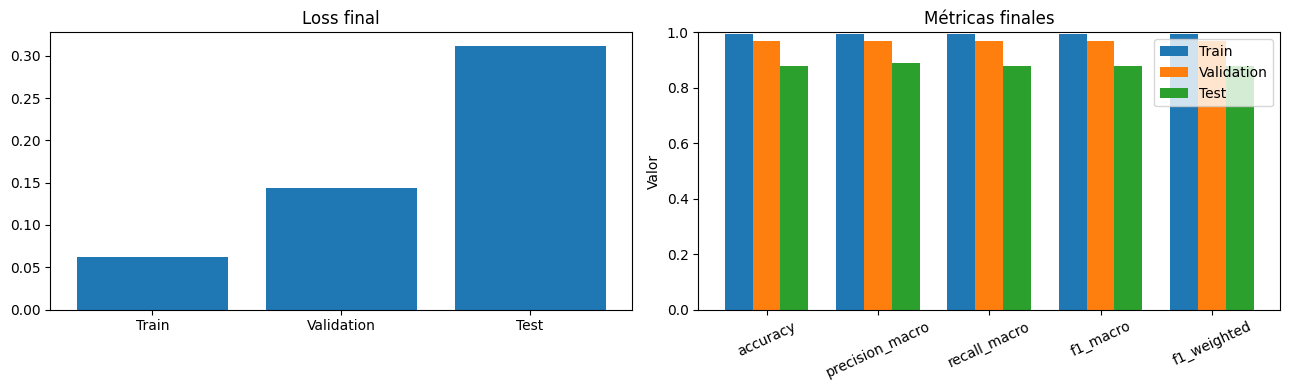

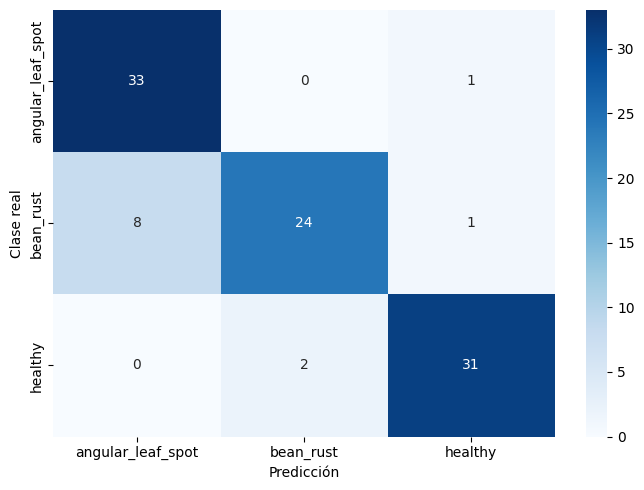

In [87]:
# Gráficos finales registrados también como artefactos en MLflow
display(curve_figure)
display(comparison_figure)
display(confusion_figure)

Para consultar la ejecución:

```bash
mlflow ui
```

Luego abrir `http://127.0.0.1:5000`.